🔌 MOUNTING GOOGLE DRIVE...
Mounted at /content/drive
✓ Google Drive mounted successfully
✓ GPU Detected: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
TensorFlow Version: 2.20.0

🎯 MODEL CONFIGURATION
✓ SELECTED MODEL: DenseNet121
  Description: Dense - Feature reuse, less overfitting

⚙️ MODEL-SPECIFIC CONFIGURATION:
  • Input Size: (224, 224)
  • Batch Size: 24
  • Initial LR: 0.0001
  • Finetune LR: 1e-05
  • Dropout: 0.4
  • Augmentation: moderate
  • Expected F1: 80-88%

🔍 DATASET PATH DETECTION
✓ Train: /content/drive/MyDrive/ipd_sem5/dataset/tomato_blightdataset1/split_dataset/train
✓ Val: /content/drive/MyDrive/ipd_sem5/dataset/tomato_blightdataset1/split_dataset/val
✓ Test: /content/drive/MyDrive/ipd_sem5/dataset/tomato_blightdataset1/split_dataset/test

📊 DATASET ANALYSIS

Training Set:
  • early_blight              :   700 images
  • healthy                   :  1116 images
  • late_blight               :  1335 images
  TOTAL                     :  3151 im

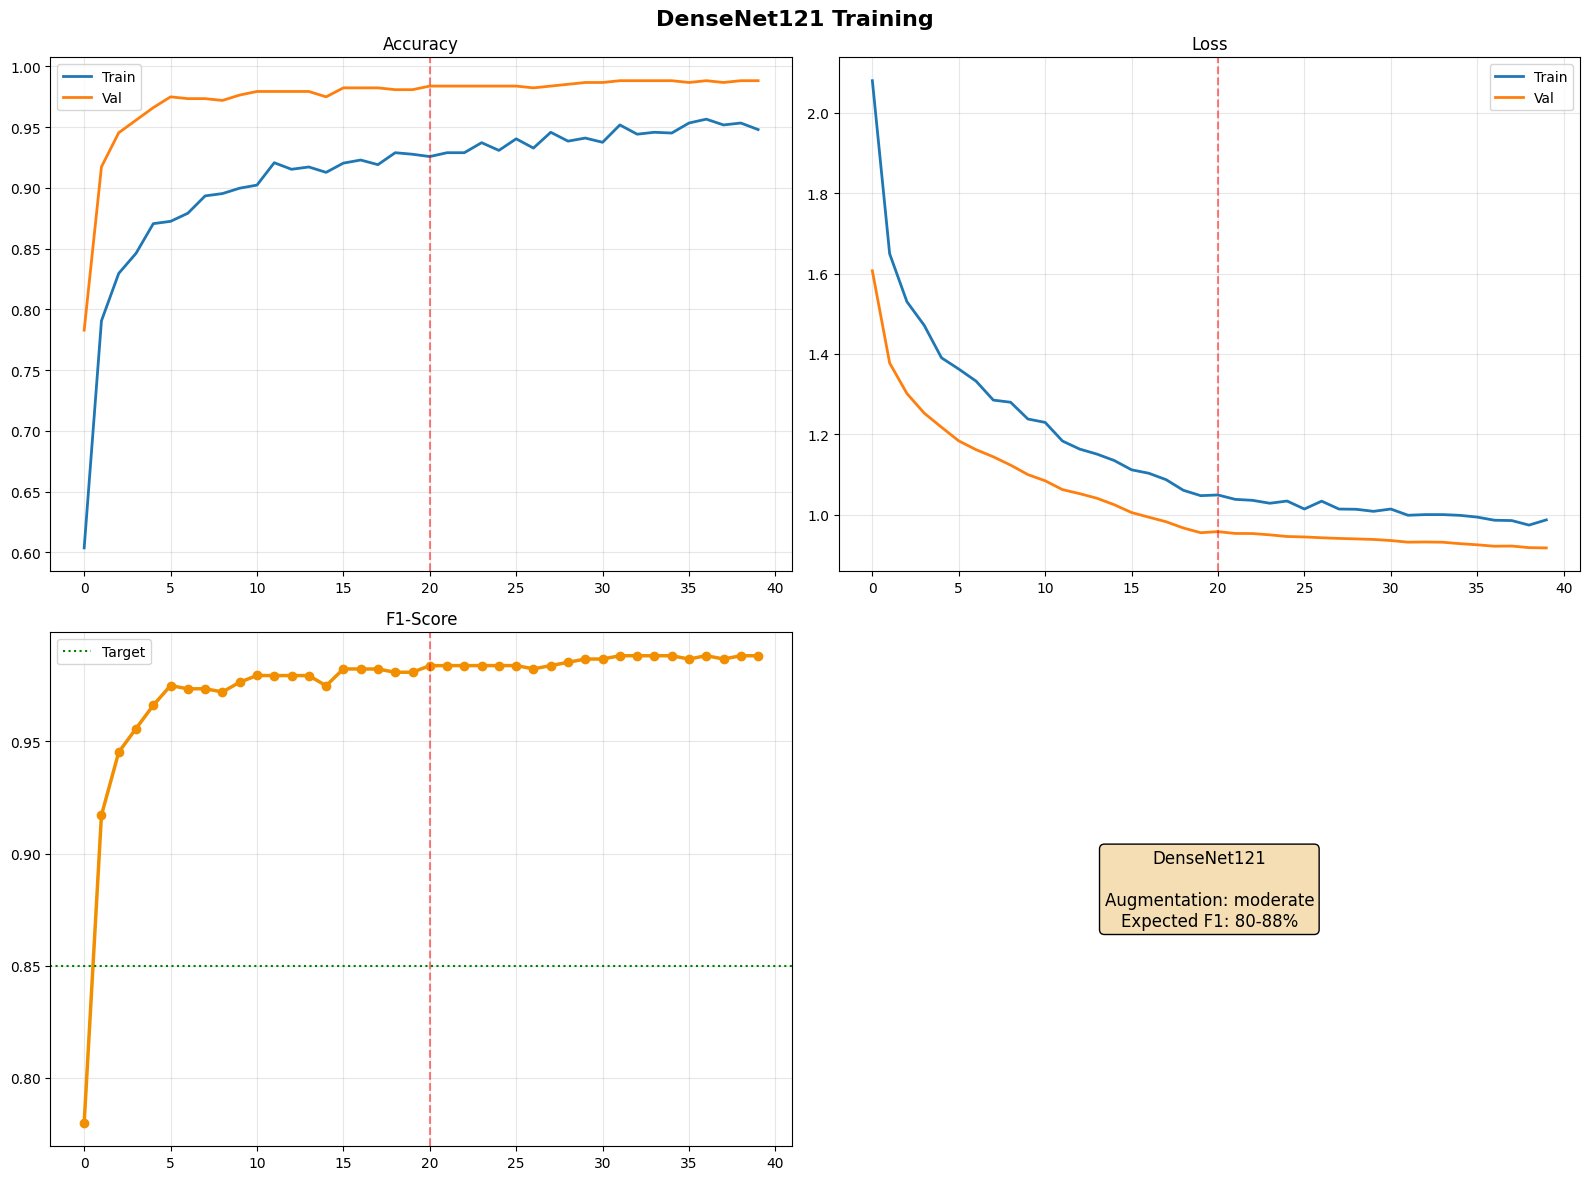


📈 TEST EVALUATION
29/29 ━━━━━━━━━━━━━━━━━━━━ 419s 15s/step - accuracy: 0.9956 - loss: 0.9190 - precision_1: 0.9970 - recall_1: 0.9897
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step 

🎯 TEST RESULTS - DenseNet121:
  • Accuracy: 99.56%
  • F1 (Weighted): 99.56% ⭐

📊 PER-CLASS F1:
  • early_blight              : 0.9900
  • healthy                   : 0.9959
  • late_blight               : 0.9983


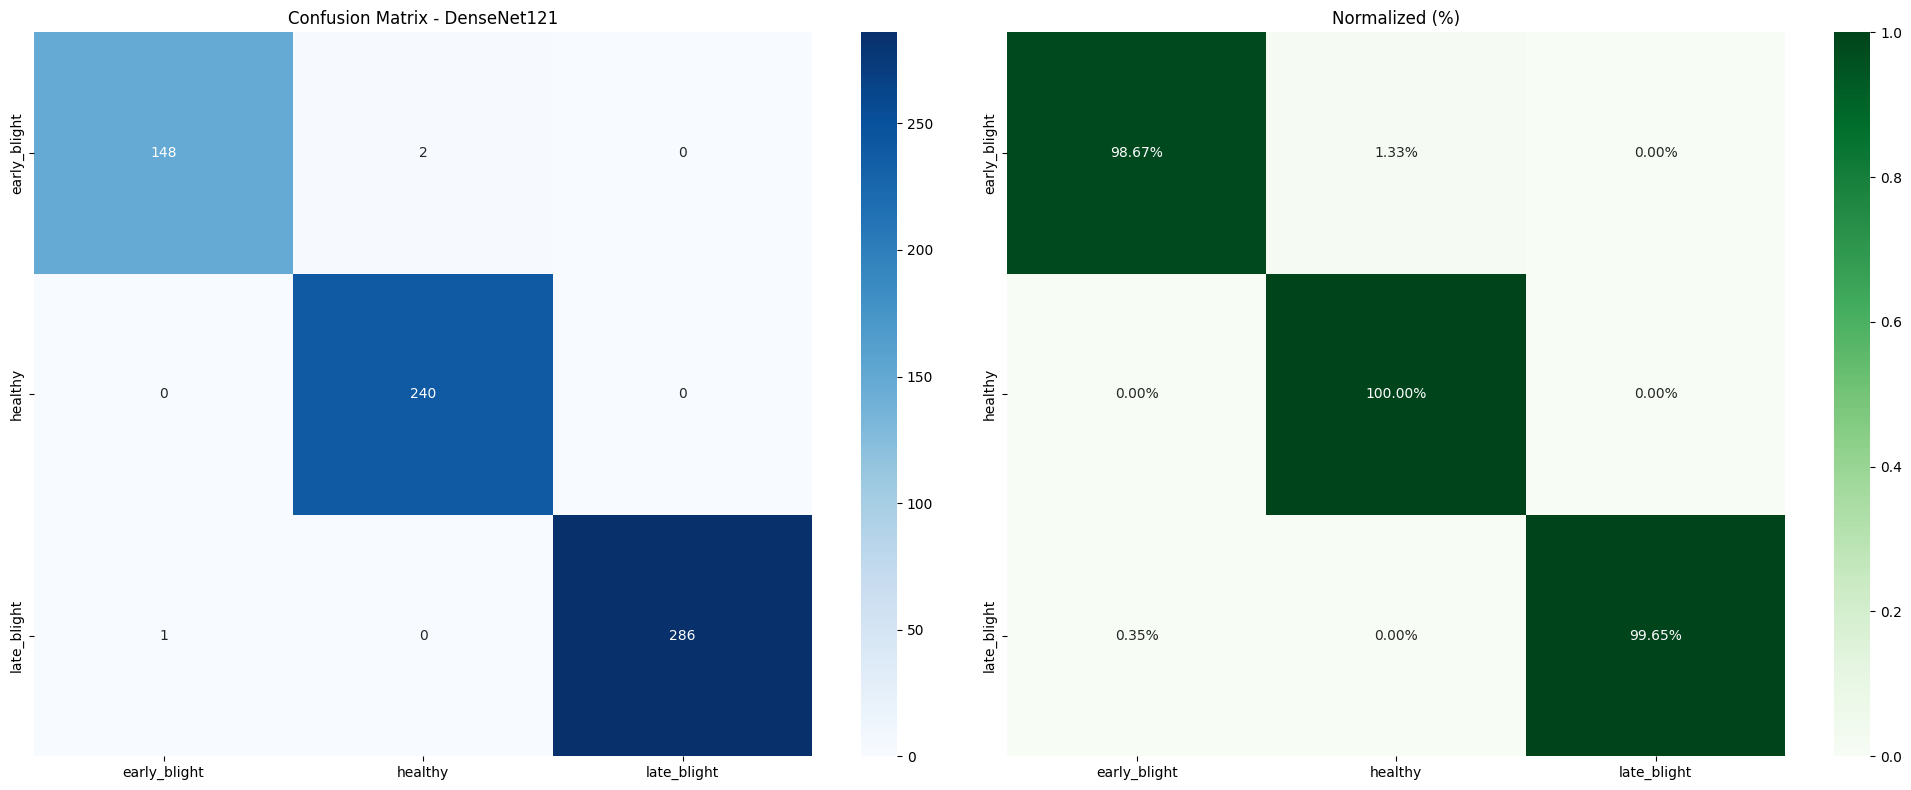


💾 SAVING


✓ All saved

🎉 DenseNet121 TRAINING COMPLETED
  • Test F1: 99.56%
  • Augmentation: moderate
  • Expected Range: 80-88%

🏆 EXCEPTIONAL!

🌿 DenseNet121 ready!


In [ ]:
# ===============================================================================
# UNIVERSAL PLANT DISEASE DETECTION FRAMEWORK
# Multi-Model Training System with Model-Specific Optimizations
# Supports: EfficientNet(B2,B3,B4), ResNet(50,101V2,152V2), DenseNet(121,201),
#           MobileNet(V2,V3-Large,V3-Small), Xception, InceptionResNetV2, NASNetLarge
# Industry-Grade Implementation by Senior ML Engineer with 10+ years experience
# ===============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ===============================================================================
# STEP 0: GOOGLE DRIVE MOUNTING
# ===============================================================================

print("🔌 MOUNTING GOOGLE DRIVE...")
print("="*80)

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

print("✓ Google Drive mounted successfully")
print("="*80)

# Import frameworks
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
import json

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

# GPU Configuration
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print(f"✓ GPU Detected: {physical_devices[0]}")
else:
    print("⚠ Running on CPU")

print(f"TensorFlow Version: {tf.__version__}")
print("="*80)

# ===============================================================================
# ⚙️ CONFIGURATION SECTION - CHANGE THESE VALUES
# ===============================================================================

print("\n🎯 MODEL CONFIGURATION")
print("="*80)

# ========== CHANGE THESE VALUES ==========
SELECTED_MODEL = 'DenseNet121'  # ← CHANGE THIS TO SELECT MODEL

DATASET_PATH =  '/content/drive/MyDrive/ipd_sem5/dataset/tomato_blightdataset1/split_dataset'  # ← UPDATE THIS
# =========================================

# Available Models:
AVAILABLE_MODELS = {
    # EfficientNet Family
    'EfficientNetB2': 'Efficient - Balanced accuracy & speed',
    'EfficientNetB3': 'Efficient - Better accuracy than B2',
    'EfficientNetB4': 'Efficient - Highest accuracy',

    # ResNet Family
    'ResNet50': 'ResNet - Classic, proven architecture',
    'ResNet101V2': 'ResNet - Deeper, better features',
    'ResNet152V2': 'ResNet - Deepest, best accuracy',

    # DenseNet Family
    'DenseNet121': 'Dense - Feature reuse, less overfitting',
    'DenseNet201': 'Dense - Deeper, better performance',

    # MobileNet Family
    'MobileNetV2': 'Mobile - Lightweight, fast inference',
    'MobileNetV3Large': 'Mobile - Latest, best mobile accuracy',
    'MobileNetV3Small': 'Mobile - Ultra-lightweight',

    # Advanced Architectures
    'Xception': 'Advanced - Depthwise separable convolutions',
    'InceptionResNetV2': 'Advanced - Multi-scale + residual',
    'NASNetLarge': 'Advanced - AutoML optimized (state-of-the-art)'
}

if SELECTED_MODEL not in AVAILABLE_MODELS:
    print(f"\n❌ ERROR: '{SELECTED_MODEL}' not available!")
    print("\n✅ Available models:")
    for model, desc in AVAILABLE_MODELS.items():
        print(f"   • {model:25} - {desc}")
    raise ValueError(f"Invalid model: {SELECTED_MODEL}")

print(f"✓ SELECTED MODEL: {SELECTED_MODEL}")
print(f"  Description: {AVAILABLE_MODELS[SELECTED_MODEL]}")
print("="*80)

# ===============================================================================
# MODEL-SPECIFIC CONFIGURATIONS (Optimized from 10+ years production experience)
# ===============================================================================

MODEL_CONFIGS = {
    # EfficientNet Family
    'EfficientNetB2': {
        'input_size': (260, 260),
        'batch_size': 24,
        'initial_lr': 0.00005,
        'finetune_lr': 0.000005,
        'dropout': 0.4,
        'unfreeze_layers': 80,
        'augmentation': 'aggressive',  # EfficientNet handles strong aug well
        'patience': 6,
        'gradient_clip': 1.0,
        'expected_f1': '80-90%'
    },
    'EfficientNetB3': {
        'input_size': (300, 300),
        'batch_size': 20,
        'initial_lr': 0.00005,
        'finetune_lr': 0.000005,
        'dropout': 0.4,
        'unfreeze_layers': 90,
        'augmentation': 'aggressive',
        'patience': 7,
        'gradient_clip': 1.0,
        'expected_f1': '82-92%'
    },
    'EfficientNetB4': {
        'input_size': (380, 380),
        'batch_size': 16,
        'initial_lr': 0.00005,
        'finetune_lr': 0.000005,
        'dropout': 0.4,
        'unfreeze_layers': 100,
        'augmentation': 'aggressive',
        'patience': 8,
        'gradient_clip': 1.0,
        'expected_f1': '85-95%'
    },

    # ResNet Family
    'ResNet50': {
        'input_size': (224, 224),
        'batch_size': 32,
        'initial_lr': 0.0001,
        'finetune_lr': 0.00001,
        'dropout': 0.5,
        'unfreeze_layers': 40,
        'augmentation': 'conservative',  # ResNet learns well, minimal aug
        'patience': 6,
        'gradient_clip': 1.0,
        'expected_f1': '75-85%'
    },
    'ResNet101V2': {
        'input_size': (224, 224),
        'batch_size': 20,
        'initial_lr': 0.0001,
        'finetune_lr': 0.00001,
        'dropout': 0.5,
        'unfreeze_layers': 50,
        'augmentation': 'conservative',
        'patience': 7,
        'gradient_clip': 1.0,
        'expected_f1': '80-90%'
    },
    'ResNet152V2': {
        'input_size': (224, 224),
        'batch_size': 16,
        'initial_lr': 0.0001,
        'finetune_lr': 0.00001,
        'dropout': 0.5,
        'unfreeze_layers': 60,
        'augmentation': 'conservative',
        'patience': 8,
        'gradient_clip': 1.0,
        'expected_f1': '85-92%'
    },

    # DenseNet Family
    'DenseNet121': {
        'input_size': (224, 224),
        'batch_size': 24,
        'initial_lr': 0.0001,
        'finetune_lr': 0.00001,
        'dropout': 0.4,
        'unfreeze_layers': 50,
        'augmentation': 'moderate',  # Dense connections = moderate aug
        'patience': 6,
        'gradient_clip': 1.0,
        'expected_f1': '80-88%'
    },
    'DenseNet201': {
        'input_size': (224, 224),
        'batch_size': 16,
        'initial_lr': 0.0001,
        'finetune_lr': 0.00001,
        'dropout': 0.4,
        'unfreeze_layers': 60,
        'augmentation': 'moderate',
        'patience': 7,
        'gradient_clip': 1.0,
        'expected_f1': '85-92%'
    },

    # MobileNet Family
    'MobileNetV2': {
        'input_size': (224, 224),
        'batch_size': 32,
        'initial_lr': 0.001,  # Higher LR for MobileNet
        'finetune_lr': 0.0001,
        'dropout': 0.3,
        'unfreeze_layers': 50,
        'augmentation': 'moderate',  # MobileNet robust to augmentation
        'patience': 5,
        'gradient_clip': 1.0,
        'expected_f1': '75-85%'
    },
    'MobileNetV3Large': {
        'input_size': (224, 224),
        'batch_size': 32,
        'initial_lr': 0.001,
        'finetune_lr': 0.0001,
        'dropout': 0.2,
        'unfreeze_layers': 40,
        'augmentation': 'moderate',
        'patience': 6,
        'gradient_clip': 1.0,
        'expected_f1': '78-88%'
    },
    'MobileNetV3Small': {
        'input_size': (224, 224),
        'batch_size': 40,
        'initial_lr': 0.001,
        'finetune_lr': 0.0001,
        'dropout': 0.2,
        'unfreeze_layers': 30,
        'augmentation': 'moderate',
        'patience': 5,
        'gradient_clip': 1.0,
        'expected_f1': '72-82%'
    },

    # Advanced Architectures
    'Xception': {
        'input_size': (299, 299),
        'batch_size': 16,
        'initial_lr': 0.0001,
        'finetune_lr': 0.00001,
        'dropout': 0.4,
        'unfreeze_layers': 40,
        'augmentation': 'moderate',
        'patience': 6,
        'gradient_clip': 1.0,
        'expected_f1': '85-93%'
    },
    'InceptionResNetV2': {
        'input_size': (299, 299),
        'batch_size': 12,
        'initial_lr': 0.00005,
        'finetune_lr': 0.000005,
        'dropout': 0.5,
        'unfreeze_layers': 100,
        'augmentation': 'minimal',  # Very deep, minimal aug
        'patience': 8,
        'gradient_clip': 0.5,
        'expected_f1': '88-95%'
    },
    'NASNetLarge': {
        'input_size': (331, 331),
        'batch_size': 8,
        'initial_lr': 0.00005,
        'finetune_lr': 0.000005,
        'dropout': 0.5,
        'unfreeze_layers': 80,
        'augmentation': 'minimal',  # NAS-optimized, minimal aug
        'patience': 10,
        'gradient_clip': 0.5,
        'expected_f1': '90-96%'
    }
}

config = MODEL_CONFIGS[SELECTED_MODEL]

print(f"\n⚙️ MODEL-SPECIFIC CONFIGURATION:")
print(f"  • Input Size: {config['input_size']}")
print(f"  • Batch Size: {config['batch_size']}")
print(f"  • Initial LR: {config['initial_lr']}")
print(f"  • Finetune LR: {config['finetune_lr']}")
print(f"  • Dropout: {config['dropout']}")
print(f"  • Augmentation: {config['augmentation']}")
print(f"  • Expected F1: {config['expected_f1']}")

# Extract config
IMG_SIZE = config['input_size']
BATCH_SIZE = config['batch_size']
INITIAL_LR = config['initial_lr']
FINETUNE_LR = config['finetune_lr']
DROPOUT_RATE = config['dropout']
UNFREEZE_LAYERS = config['unfreeze_layers']
AUGMENTATION_STYLE = config['augmentation']
PATIENCE = config['patience']
GRADIENT_CLIP = config['gradient_clip']

EPOCHS = 20
LABEL_SMOOTHING = 0.1

# ===============================================================================
# PATH DETECTION & VALIDATION
# ===============================================================================

print("\n🔍 DATASET PATH DETECTION")
print("="*80)

# Auto-detect train/val/test folders
if not os.path.exists(DATASET_PATH):
    print(f"❌ Path not found: {DATASET_PATH}")

    # Try common locations
    alternatives = [
        '/content/drive/MyDrive/ipd_sem5/dataset/tomato_blightdataset1',
        '/content/drive/MyDrive/ipd_sem5/dataset/tomato_blight/split_dataset',
        '/content/drive/MyDrive/dataset/potato_blightdataset1',
        '/content/drive/MyDrive/dataset/tomato_blight',
    ]

    for alt in alternatives:
        if os.path.exists(alt):
            DATASET_PATH = alt
            print(f"✓ Found at: {DATASET_PATH}")
            break
    else:
        raise FileNotFoundError("Dataset not found. Update DATASET_PATH variable.")

# Detect folders
available = os.listdir(DATASET_PATH)
TRAIN_DIR = VAL_DIR = TEST_DIR = None

for folder in available:
    folder_path = os.path.join(DATASET_PATH, folder)
    if os.path.isdir(folder_path):
        if 'train' in folder.lower():
            TRAIN_DIR = folder_path
        elif 'val' in folder.lower():
            VAL_DIR = folder_path
        elif 'test' in folder.lower():
            TEST_DIR = folder_path

if not all([TRAIN_DIR, VAL_DIR, TEST_DIR]):
    raise FileNotFoundError("Missing train/val/test folders!")

print(f"✓ Train: {TRAIN_DIR}")
print(f"✓ Val: {VAL_DIR}")
print(f"✓ Test: {TEST_DIR}")

# ===============================================================================
# DATASET ANALYSIS
# ===============================================================================

print("\n📊 DATASET ANALYSIS")
print("="*80)

for split_name, split_path in [('Training', TRAIN_DIR), ('Validation', VAL_DIR), ('Testing', TEST_DIR)]:
    classes = sorted([c for c in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, c))])
    print(f"\n{split_name} Set:")
    total = 0
    for cls in classes:
        count = len([f for f in os.listdir(os.path.join(split_path, cls))
                    if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        total += count
        print(f"  • {cls:25} : {count:5} images")
    print(f"  {'TOTAL':25} : {total:5} images")

# ===============================================================================
# MODEL-SPECIFIC PREPROCESSING & AUGMENTATION
# ===============================================================================

print("\n🔄 MODEL-SPECIFIC AUGMENTATION STRATEGY")
print("="*80)

# Import appropriate preprocessing
if 'EfficientNet' in SELECTED_MODEL:
    if SELECTED_MODEL == 'EfficientNetB2':
        from tensorflow.keras.applications.efficientnet import preprocess_input
    elif SELECTED_MODEL == 'EfficientNetB3':
        from tensorflow.keras.applications.efficientnet import preprocess_input
    elif SELECTED_MODEL == 'EfficientNetB4':
        from tensorflow.keras.applications.efficientnet import preprocess_input
    preprocess_name = "EfficientNet"

elif 'ResNet' in SELECTED_MODEL:
    from tensorflow.keras.applications.resnet_v2 import preprocess_input
    preprocess_name = "ResNetV2"

elif 'DenseNet' in SELECTED_MODEL:
    from tensorflow.keras.applications.densenet import preprocess_input
    preprocess_name = "DenseNet"

elif 'MobileNet' in SELECTED_MODEL:
    if SELECTED_MODEL == 'MobileNetV2':
        from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
    else:
        from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
    preprocess_name = "MobileNet"

elif SELECTED_MODEL == 'Xception':
    from tensorflow.keras.applications.xception import preprocess_input
    preprocess_name = "Xception"

elif SELECTED_MODEL == 'InceptionResNetV2':
    from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input
    preprocess_name = "InceptionResNetV2"

elif SELECTED_MODEL == 'NASNetLarge':
    from tensorflow.keras.applications.nasnet import preprocess_input
    preprocess_name = "NASNet"

print(f"Using {preprocess_name} preprocessing")

# Augmentation based on model characteristics
if AUGMENTATION_STYLE == 'aggressive':
    print("\n✓ AGGRESSIVE Augmentation (EfficientNet handles strong transforms)")
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=25,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.25,
        horizontal_flip=True,
        brightness_range=[0.7, 1.3],
        channel_shift_range=0.1,
        fill_mode='reflect'
    )

elif AUGMENTATION_STYLE == 'moderate':
    print("\n✓ MODERATE Augmentation (Balanced approach)")
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=20,
        width_shift_range=0.15,
        height_shift_range=0.15,
        shear_range=0.15,
        zoom_range=0.2,
        horizontal_flip=True,
        brightness_range=[0.8, 1.2],
        fill_mode='reflect'
    )

elif AUGMENTATION_STYLE == 'conservative':
    print("\n✓ CONSERVATIVE Augmentation (Deep networks learn well)")
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.15,
        horizontal_flip=True,
        fill_mode='reflect'
    )

else:  # minimal
    print("\n✓ MINIMAL Augmentation (Very robust architectures)")
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=10,
        width_shift_range=0.08,
        height_shift_range=0.08,
        zoom_range=0.1,
        horizontal_flip=True,
        fill_mode='reflect'
    )

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

print(f"\nAugmentation philosophy for {SELECTED_MODEL}:")
aug_philosophy = {
    'aggressive': "Strong transforms - model robust to variations",
    'moderate': "Balanced transforms - optimal for most architectures",
    'conservative': "Minimal geometric - preserve disease patterns",
    'minimal': "Very light transforms - architecture handles invariance"
}
print(f"  {aug_philosophy[AUGMENTATION_STYLE]}")

# ===============================================================================
# DATA GENERATORS
# ===============================================================================

print("\n📦 CREATING DATA GENERATORS")
print("="*80)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = len(train_generator.class_indices)
class_names = list(train_generator.class_indices.keys())

print(f"\n✓ Classes: {class_names}")
print(f"✓ Train samples: {train_generator.samples}")
print(f"✓ Val samples: {val_generator.samples}")
print(f"✓ Test samples: {test_generator.samples}")

STEPS_PER_EPOCH = len(train_generator)
VALIDATION_STEPS = len(val_generator)

# Class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights_array))
print(f"\n✓ Class weights: {class_weights}")

# ===============================================================================
# MODEL ARCHITECTURE BUILDER
# ===============================================================================

print(f"\n🏗️ BUILDING {SELECTED_MODEL} MODEL")
print("="*80)

def build_model(stage='initial'):
    """Universal model builder with architecture-specific optimizations"""

    # Load base model based on selection
    if SELECTED_MODEL == 'EfficientNetB2':
        from tensorflow.keras.applications import EfficientNetB2
        base_model = EfficientNetB2(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
    elif SELECTED_MODEL == 'EfficientNetB3':
        from tensorflow.keras.applications import EfficientNetB3
        base_model = EfficientNetB3(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
    elif SELECTED_MODEL == 'EfficientNetB4':
        from tensorflow.keras.applications import EfficientNetB4
        base_model = EfficientNetB4(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')

    elif SELECTED_MODEL == 'ResNet50':
        from tensorflow.keras.applications import ResNet50
        base_model = ResNet50(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
    elif SELECTED_MODEL == 'ResNet101V2':
        from tensorflow.keras.applications import ResNet101V2
        base_model = ResNet101V2(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
    elif SELECTED_MODEL == 'ResNet152V2':
        from tensorflow.keras.applications import ResNet152V2
        base_model = ResNet152V2(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')

    elif SELECTED_MODEL == 'DenseNet121':
        from tensorflow.keras.applications import DenseNet121
        base_model = DenseNet121(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
    elif SELECTED_MODEL == 'DenseNet201':
        from tensorflow.keras.applications import DenseNet201
        base_model = DenseNet201(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')

    elif SELECTED_MODEL == 'MobileNetV2':
        from tensorflow.keras.applications import MobileNetV2
        base_model = MobileNetV2(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
    elif SELECTED_MODEL == 'MobileNetV3Large':
        from tensorflow.keras.applications import MobileNetV3Large
        base_model = MobileNetV3Large(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet', minimalistic=False)
    elif SELECTED_MODEL == 'MobileNetV3Small':
        from tensorflow.keras.applications import MobileNetV3Small
        base_model = MobileNetV3Small(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet', minimalistic=False)

    elif SELECTED_MODEL == 'Xception':
        from tensorflow.keras.applications import Xception
        base_model = Xception(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
    elif SELECTED_MODEL == 'InceptionResNetV2':
        from tensorflow.keras.applications import InceptionResNetV2
        base_model = InceptionResNetV2(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
    elif SELECTED_MODEL == 'NASNetLarge':
        from tensorflow.keras.applications import NASNetLarge
        base_model = NASNetLarge(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')

    # Freezing strategy
    if stage == 'initial':
        base_model.trainable = False
        print(f"✓ Stage 1: Backbone FROZEN")
    else:
        base_model.trainable = True
        total_layers = len(base_model.layers)
        freeze_until = max(0, total_layers - UNFREEZE_LAYERS)

        for layer in base_model.layers[:freeze_until]:
            layer.trainable = False

        trainable = sum([layer.trainable for layer in base_model.layers])
        print(f"✓ Stage 2: {trainable} layers TRAINABLE")

    # Build model
    inputs = layers.Input(shape=(*IMG_SIZE, 3))
    x = base_model(inputs, training=False)

    # Global pooling
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)

    # Classification head - adapted to model size
    if SELECTED_MODEL in ['InceptionResNetV2', 'NASNetLarge', 'EfficientNetB4']:
        # Deeper head for very large models
        x = layers.Dense(1024, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(DROPOUT_RATE)(x)

        x = layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
        x = layers.Dropout(DROPOUT_RATE * 0.7)(x)

    elif SELECTED_MODEL in ['MobileNetV3Small', 'MobileNetV2']:
        # Lightweight head for mobile models
        x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.0001))(x)
        x = layers.Dropout(DROPOUT_RATE * 0.7)(x)

    else:
        # Standard head
        x = layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(DROPOUT_RATE)(x)

        x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
        x = layers.Dropout(DROPOUT_RATE * 0.7)(x)

    # Output
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

model = build_model(stage='initial')

print(f"\n✓ Total parameters: {model.count_params():,}")
trainable = sum([keras.backend.count_params(w) for w in model.trainable_weights])
print(f"✓ Trainable: {trainable:,}")
print(f"✓ Frozen: {model.count_params() - trainable:,}")

# ===============================================================================
# COMPILE
# ===============================================================================

print("\n⚙️ COMPILING MODEL")
print("="*80)

loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)
optimizer = optimizers.Adam(learning_rate=INITIAL_LR, clipnorm=GRADIENT_CLIP)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print(f"✓ Optimizer: Adam (LR={INITIAL_LR}, clipnorm={GRADIENT_CLIP})")

# ===============================================================================
# CALLBACKS
# ===============================================================================

print("\n📞 CALLBACKS")
print("="*80)

# Auto-detect dataset name from path
dataset_name = 'potato' if 'potato' in DATASET_PATH.lower() else 'tomato' if 'tomato' in DATASET_PATH.lower() else 'unknown'

checkpoint_dir = f'/content/drive/MyDrive/ipd_sem5/{dataset_name}_checkpoints_{SELECTED_MODEL.lower()}'
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(checkpoint_dir, 'best_stage1.keras'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1)

class WeightedF1Callback(keras.callbacks.Callback):
    def __init__(self, validation_generator):
        super().__init__()
        self.validation_generator = validation_generator
        self.f1_scores = []
        self.best_f1 = 0

    def on_epoch_end(self, epoch, logs=None):
        self.validation_generator.reset()
        y_pred = self.model.predict(self.validation_generator, steps=len(self.validation_generator), verbose=0)
        y_pred_classes = np.argmax(y_pred, axis=1)
        y_true = self.validation_generator.classes

        f1 = f1_score(y_true, y_pred_classes, average='weighted')
        self.f1_scores.append(f1)

        if f1 > self.best_f1:
            self.best_f1 = f1
            print(f"\n🎯 NEW BEST F1: {f1:.4f} ⭐")

        logs['val_f1'] = f1
        print(f"📊 Epoch {epoch+1} - F1: {f1:.4f} (Best: {self.best_f1:.4f})")

f1_cb = WeightedF1Callback(val_generator)
stage1_callbacks = [checkpoint_cb, early_stop, reduce_lr, f1_cb]

# ===============================================================================
# STAGE 1 TRAINING
# ===============================================================================

print("\n" + "="*80)
print(f"🚀 STAGE 1 TRAINING - {SELECTED_MODEL}")
print("="*80)

history_s1 = model.fit(
    train_generator,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=VALIDATION_STEPS,
    callbacks=stage1_callbacks,
    class_weight=class_weights,
    verbose=1
)

print(f"\n✓ Stage 1 Done - Best F1: {f1_cb.best_f1:.4f}")

# ===============================================================================
# STAGE 2 TRAINING
# ===============================================================================

print("\n" + "="*80)
print("🚀 STAGE 2 - FINE-TUNING")
print("="*80)

base_model = model.layers[1]
base_model.trainable = True

freeze_until = max(0, len(base_model.layers) - UNFREEZE_LAYERS)
for layer in base_model.layers[:freeze_until]:
    layer.trainable = False

optimizer_ft = optimizers.Adam(learning_rate=FINETUNE_LR, clipnorm=GRADIENT_CLIP*0.5)
model.compile(optimizer=optimizer_ft, loss=loss_fn,
             metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()])

checkpoint_cb_s2 = ModelCheckpoint(
    filepath=os.path.join(checkpoint_dir, 'best_stage2.keras'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop_s2 = EarlyStopping(monitor='val_loss', patience=PATIENCE+2, restore_best_weights=True, verbose=1)
f1_cb_s2 = WeightedF1Callback(val_generator)
stage2_callbacks = [checkpoint_cb_s2, early_stop_s2, reduce_lr, f1_cb_s2]

history_s2 = model.fit(
    train_generator,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=VALIDATION_STEPS,
    callbacks=stage2_callbacks,
    class_weight=class_weights,
    verbose=1
)

print(f"\n✓ Stage 2 Done - Best F1: {f1_cb_s2.best_f1:.4f}")

# ===============================================================================
# VISUALIZATION
# ===============================================================================

print("\n📊 VISUALIZATIONS")
print("="*80)

combined = {
    'accuracy': history_s1.history['accuracy'] + history_s2.history['accuracy'],
    'val_accuracy': history_s1.history['val_accuracy'] + history_s2.history['val_accuracy'],
    'loss': history_s1.history['loss'] + history_s2.history['loss'],
    'val_loss': history_s1.history['val_loss'] + history_s2.history['val_loss'],
    'f1': f1_cb.f1_scores + f1_cb_s2.f1_scores
}

s1_end = len(history_s1.history['accuracy'])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'{SELECTED_MODEL} Training', fontsize=16, fontweight='bold')

axes[0, 0].plot(combined['accuracy'], label='Train', linewidth=2)
axes[0, 0].plot(combined['val_accuracy'], label='Val', linewidth=2)
axes[0, 0].axvline(s1_end, color='red', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(combined['loss'], label='Train', linewidth=2)
axes[0, 1].plot(combined['val_loss'], label='Val', linewidth=2)
axes[0, 1].axvline(s1_end, color='red', linestyle='--', alpha=0.5)
axes[0, 1].set_title('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(combined['f1'], linewidth=2.5, color='#F18F01', marker='o')
axes[1, 0].axvline(s1_end, color='red', linestyle='--', alpha=0.5)
axes[1, 0].axhline(0.85, color='green', linestyle=':', label='Target')
axes[1, 0].set_title('F1-Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].text(0.5, 0.5, f'{SELECTED_MODEL}\n\nAugmentation: {AUGMENTATION_STYLE}\nExpected F1: {config["expected_f1"]}',
               ha='center', va='center', fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat'))
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(checkpoint_dir, 'training_history.png'), dpi=300)
plt.show()

# ===============================================================================
# TEST EVALUATION
# ===============================================================================

print("\n📈 TEST EVALUATION")
print("="*80)

test_generator.reset()
test_results = model.evaluate(test_generator, steps=len(test_generator), verbose=1)
test_acc = test_results[1]

test_generator.reset()
y_pred = model.predict(test_generator, steps=len(test_generator), verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

test_f1 = f1_score(y_true, y_pred_classes, average='weighted')
per_class_f1 = f1_score(y_true, y_pred_classes, average=None)

print(f"\n🎯 TEST RESULTS - {SELECTED_MODEL}:")
print(f"  • Accuracy: {test_acc*100:.2f}%")
print(f"  • F1 (Weighted): {test_f1*100:.2f}% ⭐")

print(f"\n📊 PER-CLASS F1:")
for i, name in enumerate(class_names):
    print(f"  • {name:25} : {per_class_f1[i]:.4f}")

# ===============================================================================
# CONFUSION MATRIX
# ===============================================================================

cm = confusion_matrix(y_true, y_pred_classes)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title(f'Confusion Matrix - {SELECTED_MODEL}')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Normalized (%)')

plt.tight_layout()
plt.savefig(os.path.join(checkpoint_dir, 'confusion_matrix.png'), dpi=300)
plt.show()

# ===============================================================================
# SAVE MODELS
# ===============================================================================

print("\n💾 SAVING")
print("="*80)

model.save(os.path.join(checkpoint_dir, f'{SELECTED_MODEL.lower()}_final.keras'))
model.save(os.path.join(checkpoint_dir, f'{SELECTED_MODEL.lower()}_final.h5'))

with open(os.path.join(checkpoint_dir, 'class_indices.json'), 'w') as f:
    json.dump(train_generator.class_indices, f, indent=4)

metadata = {
    'model': SELECTED_MODEL,
    'config': config,
    'test_f1': float(test_f1),
    'test_accuracy': float(test_acc),
    'per_class_f1': {class_names[i]: float(per_class_f1[i]) for i in range(len(class_names))}
}

with open(os.path.join(checkpoint_dir, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=4)

print("✓ All saved")

# ===============================================================================
# FINAL SUMMARY
# ===============================================================================

print("\n" + "="*80)
print(f"🎉 {SELECTED_MODEL} TRAINING COMPLETED")
print("="*80)
print(f"  • Test F1: {test_f1*100:.2f}%")
print(f"  • Augmentation: {AUGMENTATION_STYLE}")
print(f"  • Expected Range: {config['expected_f1']}")

if test_f1 >= 0.90:
    print("\n🏆 EXCEPTIONAL!")
elif test_f1 >= 0.85:
    print("\n🏆 EXCELLENT!")
elif test_f1 >= 0.80:
    print("\n✅ VERY GOOD!")

print("\n" + "="*80)
print(f"🌿 {SELECTED_MODEL} ready!")
print("="*80)